# **Feature EDA**

Inspect the output of `build_features()` — the engineered feature set for Models A/B/C — before training.

Goals:
- Check numeric feature distributions for sanity (no unexpected constants, no blown-up tails).
- Check categorical feature cardinality (`def_index`, `paint_seed` are high-cardinality — CatBoost/LightGBM territory, not one-hot).
- Look at each feature's raw x/y relationship with `target_b` (`log(price/ref_base_price)`) and `target_c` (`log(price/ref_predicted_price)`), individually.
- Compute correlation/covariance across numeric features + targets to spot redundant features and rank raw linear signal.

This informs which features are worth keeping/transforming for Model A (linear) and gives an intuition check before the GBDTs (Models B/C) run.

## **1. Load env vars**

In [1]:
%load_ext dotenv
%dotenv

## **2. Connect + Pull + Build Features**

In [8]:
from typing import List, Dict, Any
import sys
from turtle import pd
sys.path.insert(0, '..') # to establish root project
import os

import clickhouse_connect
import pandas as pd
import polars as pl
import numpy as np

from src.features.build_features import build_features
from src.features.temporal_split import temporal_split
from src.models.eval import rmse_log, mdape_backtransformed

ch_user: str = os.getenv('CLICKHOUSE_USER')
ch_pass: str = os.getenv('CLICKHOUSE_PASSWORD')

plot_dir: str = './plots'
os.makedirs(plot_dir, exist_ok=True)
client = clickhouse_connect.get_client(host='localhost', port=8023, username=ch_user, password=ch_pass)
sql_file_path: str = '../sql/003_csfloat_feature_eng.sql'

with open(sql_file_path, 'r') as f:
    query = f.read()


result: pd.DataFrame | pl.DataFrame = client.query_df(query)
result = pl.from_pandas(result)

df = build_features(result)
print(f"After feature build (quality + apex filter): {len(df):,}")
print(f"Columns: {df.columns}")
df.head(5)

After feature build (quality + apex filter): 413,423
Columns: ['float_value', 'float_position_in_bucket', 'n_stickers', 'total_sticker_value', 'max_sticker_value', 'sticker_to_base_ratio', 'fade_pct', 'fade_rank', 'fade_type', 'blue_gem_playside', 'keychain_ref_price', 'def_index', 'paint_seed', 'rarity', 'wear_name', 'is_stattrak', 'is_souvenir', 'target_b', 'target_c', 'sold_at']


float_value,float_position_in_bucket,n_stickers,total_sticker_value,max_sticker_value,sticker_to_base_ratio,fade_pct,fade_rank,fade_type,blue_gem_playside,keychain_ref_price,def_index,paint_seed,rarity,wear_name,is_stattrak,is_souvenir,target_b,target_c,sold_at
f32,f32,u32,i32,i32,f64,f64,u32,str,f64,i32,u16,u32,u8,str,bool,bool,f64,f64,datetime[μs]
0.099572,0.369656,0,0,0,0.0,0.0,0,"""none""",0.0,0,39,959,4,"""Minimal Wear""",false,false,0.268264,-0.012987,2026-08-02 02:33:28.522759
0.119942,0.624272,0,0,0,0.0,0.0,0,"""none""",0.0,0,39,265,4,"""Minimal Wear""",false,false,-0.079407,-0.071744,2026-07-31 09:02:52.659709
0.119022,0.612777,0,0,0,0.0,0.0,0,"""none""",0.0,0,39,315,4,"""Minimal Wear""",false,false,-0.063013,-0.063013,2026-07-31 09:38:50.806833
0.106401,0.455017,0,0,0,0.0,0.0,0,"""none""",0.0,0,39,782,4,"""Minimal Wear""",false,false,0.073025,0.050552,2026-08-03 17:31:36.169383
0.134371,0.804637,0,0,0,0.0,0.0,0,"""none""",0.0,0,39,511,4,"""Minimal Wear""",false,false,-0.035091,-0.0177,2026-07-31 03:06:19.676939


## **3. Numeric vs Categorical Split**

In [9]:
numeric_cols: List[str] = [
    'float_value', 'float_position_in_bucket', 'n_stickers',
    'total_sticker_value', 'max_sticker_value', 'sticker_to_base_ratio',
    'fade_pct', 'fade_rank', 'blue_gem_playside', 'keychain_ref_price'
]

cat_cols: List[str] = [
    'def_index', 'paint_seed', 'rarity', 'fade_type', 'wear_name',
    'is_stattrak', 'is_souvenir'
]

target_cols: List[str] = ['target_b', 'target_c']

df_numeric: pl.DataFrame = df.select(numeric_cols + target_cols)
df_cat: pl.DataFrame = df.select(cat_cols)

df_numeric.head()

float_value,float_position_in_bucket,n_stickers,total_sticker_value,max_sticker_value,sticker_to_base_ratio,fade_pct,fade_rank,blue_gem_playside,keychain_ref_price,target_b,target_c
f32,f32,u32,i32,i32,f64,f64,u32,f64,i32,f64,f64
0.099572,0.369656,0,0,0,0.0,0.0,0,0.0,0,0.268264,-0.012987
0.119942,0.624272,0,0,0,0.0,0.0,0,0.0,0,-0.079407,-0.071744
0.119022,0.612777,0,0,0,0.0,0.0,0,0.0,0,-0.063013,-0.063013
0.106401,0.455017,0,0,0,0.0,0.0,0,0.0,0,0.073025,0.050552
0.134371,0.804637,0,0,0,0.0,0.0,0,0.0,0,-0.035091,-0.0177


## **4. Categorical Feature Cardinality & Value Counts**

In [10]:
low_card_cols: list[str] = ['wear_name', 'fade_type', 'is_stattrak', 'is_souvenir', 'rarity']

for col in low_card_cols:
    vc = df_cat[col].value_counts().sort('count', descending=True)
    print(f"\n--- {col} ({df_cat[col].n_unique()} unique) ---")
    print(vc.to_pandas().to_string(index=False))

print(f"\n--- def_index ({df_cat['def_index'].n_unique()} unique, top 20) ---")
print(df_cat['def_index'].value_counts().sort('count', descending=True).head(20).to_pandas().to_string(index=False))

print(f"\n--- paint_seed ({df_cat['paint_seed'].n_unique()} unique) ---")


--- wear_name (5 unique) ---
     wear_name  count
  Minimal Wear  97618
  Field-Tested  94615
   Factory New  93245
     Well-Worn  63993
Battle-Scarred  63952

--- fade_type (4 unique) ---
 fade_type  count
      none 410135
      fade   1827
amber-fade   1383
 acid-fade     78

--- is_stattrak (1 unique) ---
 is_stattrak  count
       False 413423

--- is_souvenir (1 unique) ---
 is_souvenir  count
       False 413423

--- rarity (7 unique) ---
 rarity  count
      3 117272
      4  85474
      6  60134
      5  56804
      2  49474
      1  44094
      7    171

--- def_index (40 unique, top 20) ---
 def_index  count
         7  23102
         4  19687
        17  17335
         9  17084
        19  16751
        13  16665
        16  16556
        34  16545
         1  16538
        36  16219
        10  15509
         2  15074
        60  14941
         3  14556
        30  13882
         8  13532
        33  13358
        40  12982
        39  11659
        26  10882

--- paint

## **5. Numeric Feature Distributions**

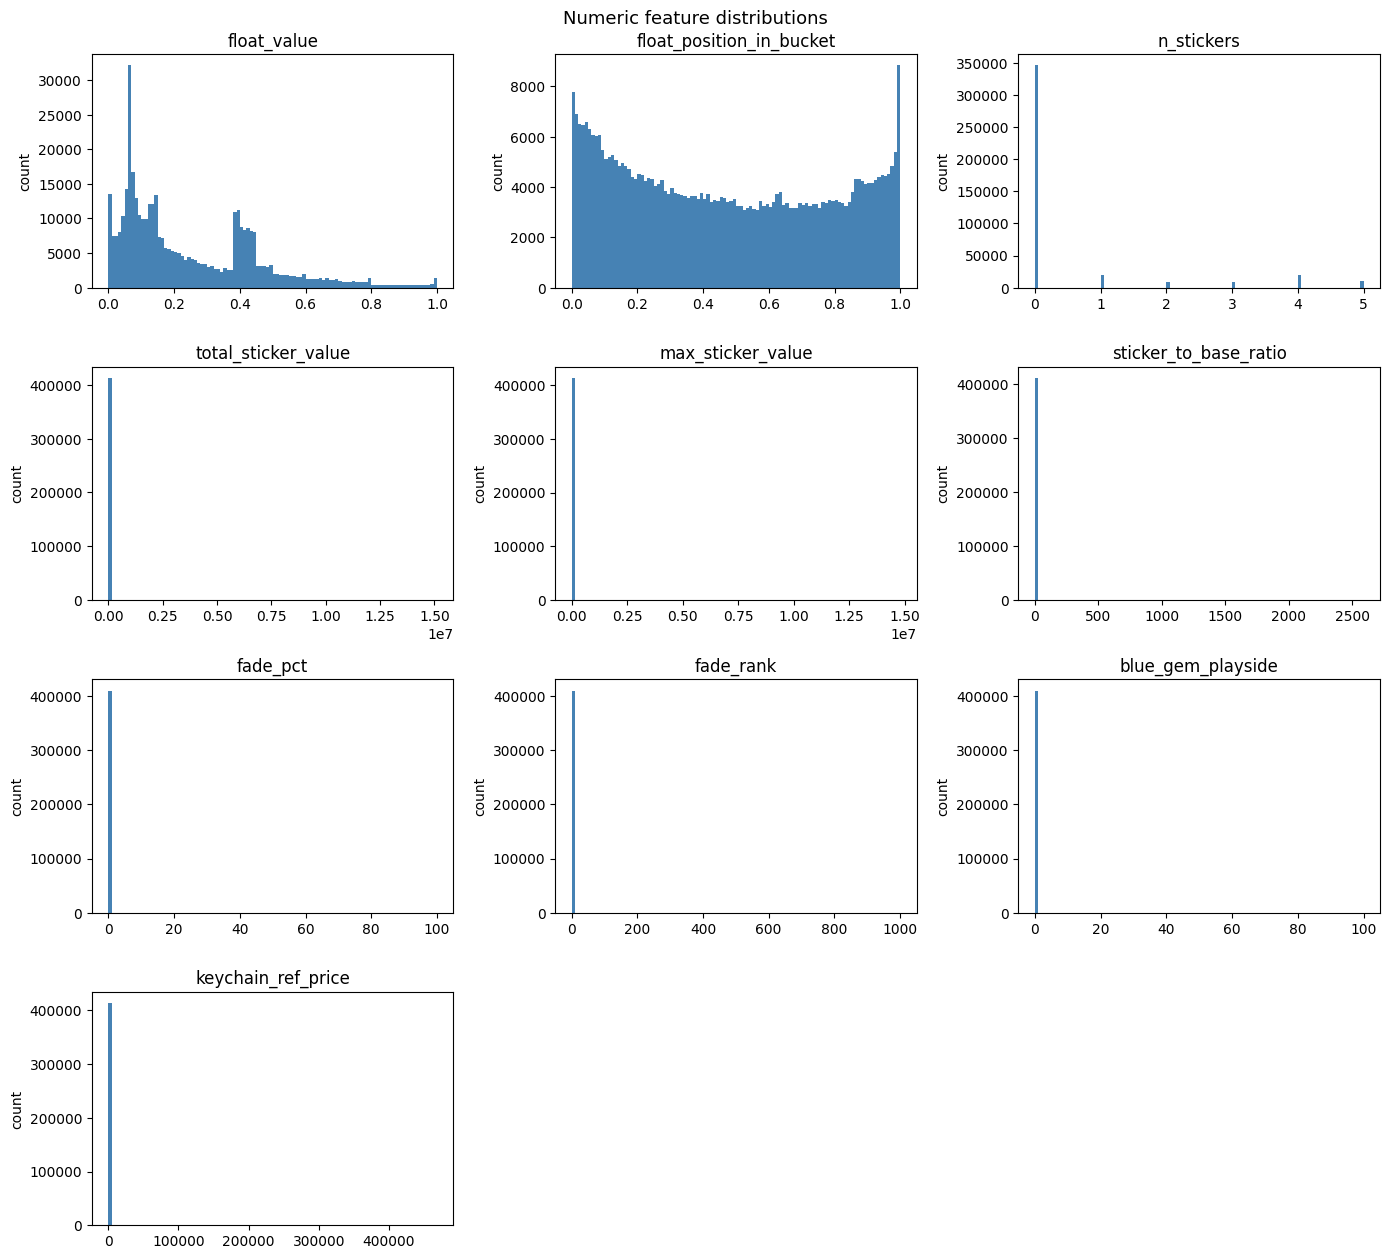

In [11]:
import matplotlib.pyplot as plt

n_cols: int = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceil div
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(df_numeric[col].to_numpy(), bins=100, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_ylabel('count')

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle('Numeric feature distributions', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'feature_distributions.png'), dpi=120, bbox_inches='tight')
plt.show()

## **6. Correlation & Covariance Matrices**

In [12]:
df_numeric[df_numeric.columns[:-2]]

float_value,float_position_in_bucket,n_stickers,total_sticker_value,max_sticker_value,sticker_to_base_ratio,fade_pct,fade_rank,blue_gem_playside,keychain_ref_price
f32,f32,u32,i32,i32,f64,f64,u32,f64,i32
0.099572,0.369656,0,0,0,0.0,0.0,0,0.0,0
0.119942,0.624272,0,0,0,0.0,0.0,0,0.0,0
0.119022,0.612777,0,0,0,0.0,0.0,0,0.0,0
0.106401,0.455017,0,0,0,0.0,0.0,0,0.0,0
0.134371,0.804637,0,0,0,0.0,0.0,0,0.0,0
…,…,…,…,…,…,…,…,…,…
0.250043,0.43497,0,0,0,0.0,0.0,0,0.0,0
0.273501,0.536962,5,8,3,0.148148,0.0,0,0.0,0
0.238335,0.384066,0,0,0,0.0,0.0,0,0.0,0


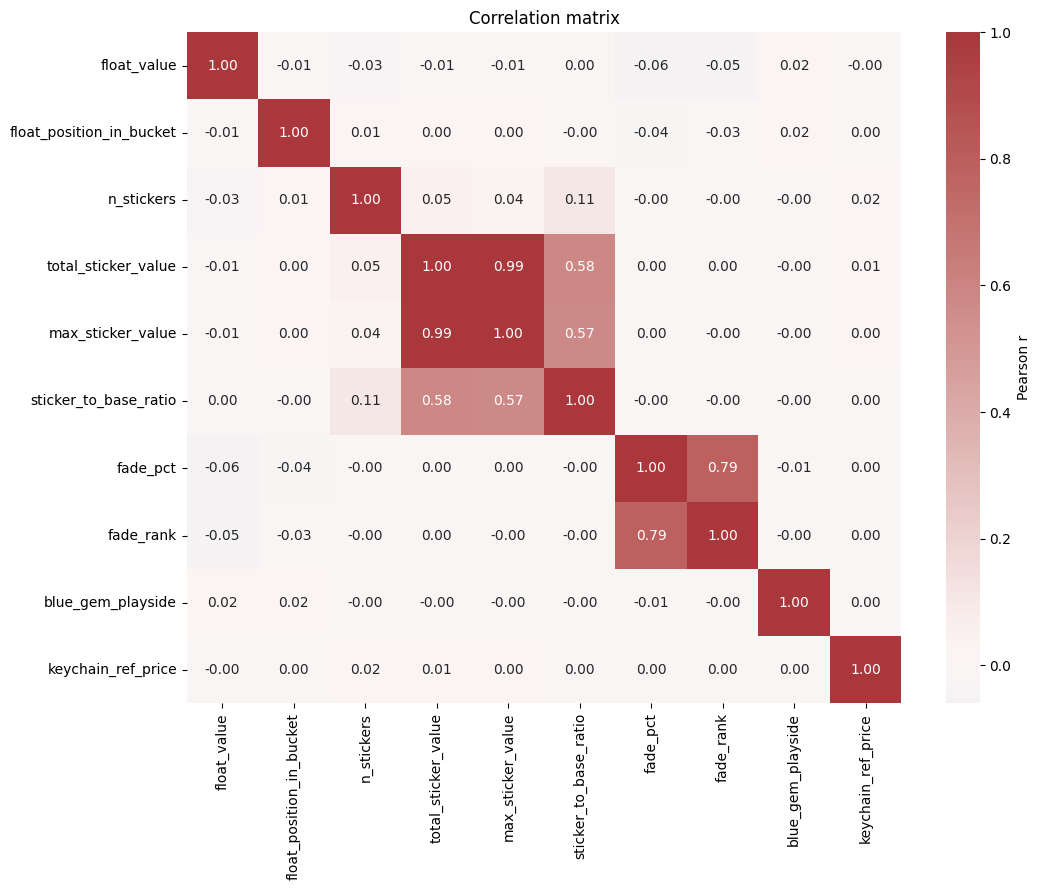

In [13]:
import seaborn as sns

non_target_cols = df_numeric.columns[:-2]

corr_df = df_numeric[non_target_cols].to_pandas()
corr_mat = corr_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation matrix')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'feature_corr.png'), dpi=120, bbox_inches='tight')
plt.show()

## **7. Target vs Numeric Feature (X–Y relationships)**

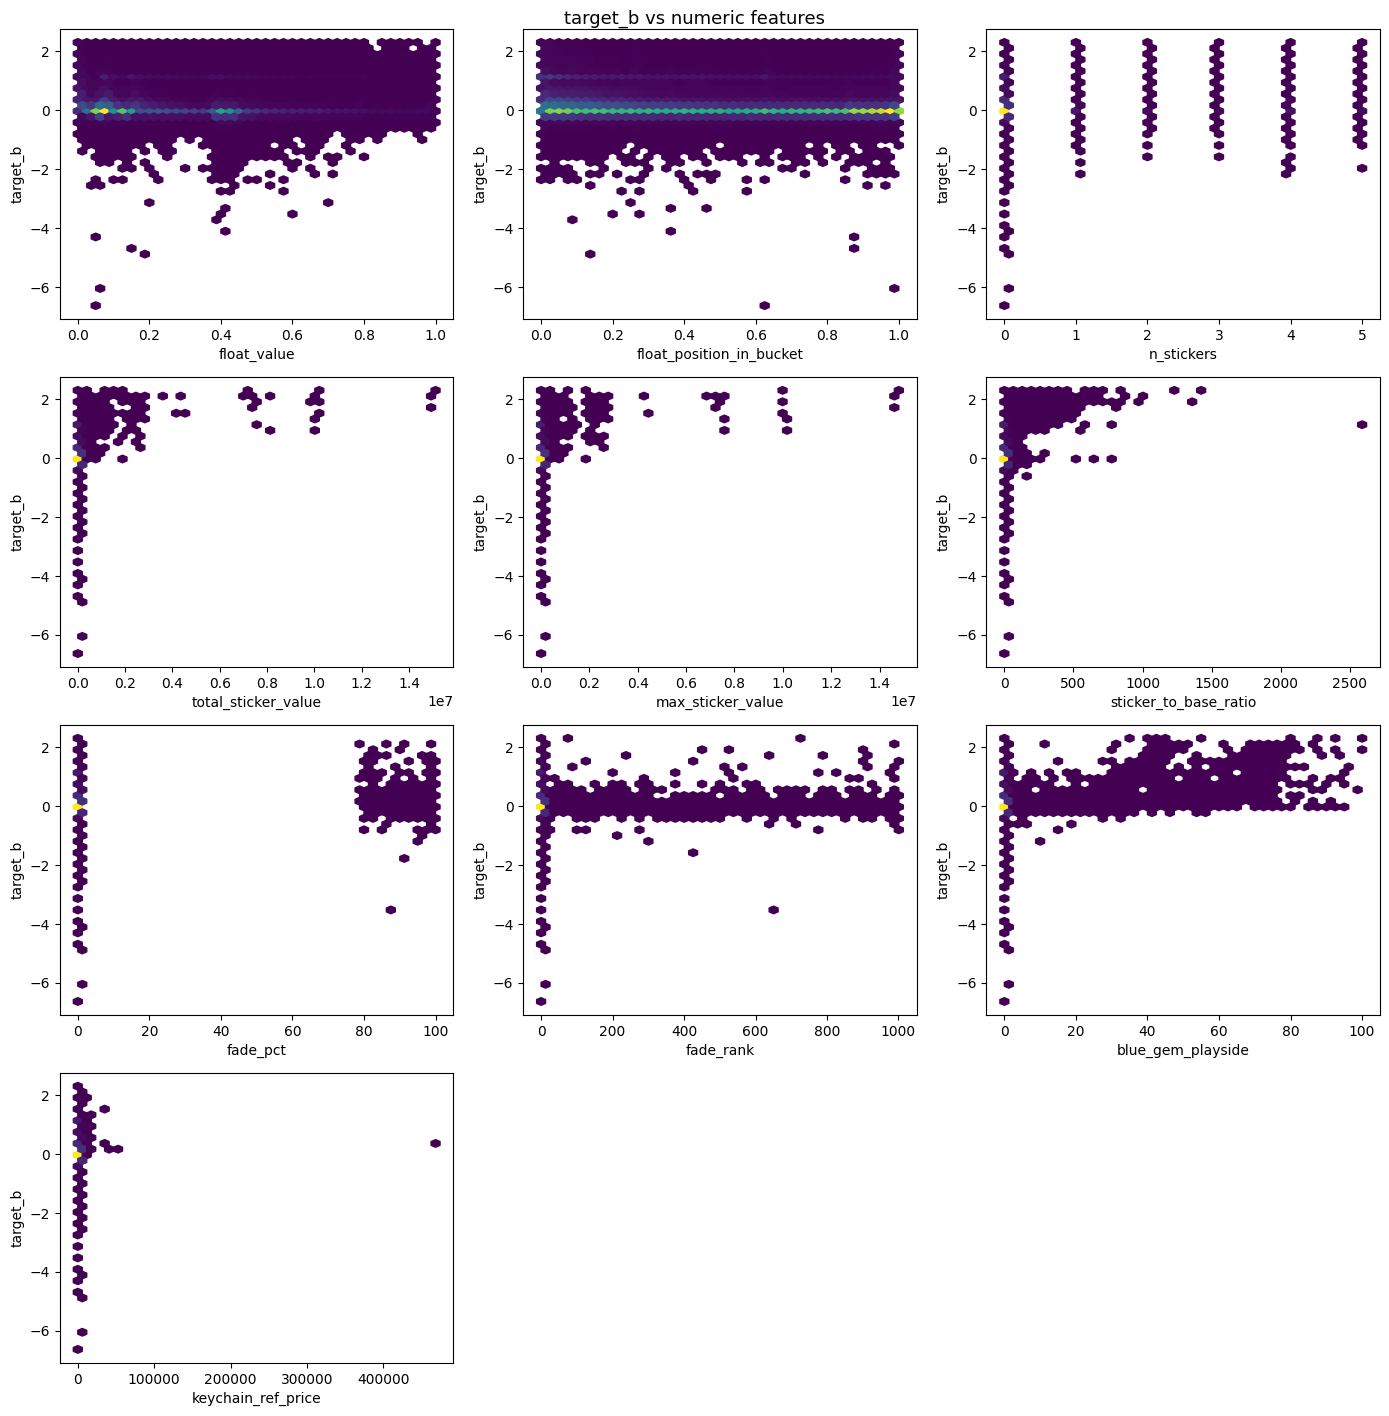

In [14]:
def target_num_rel(target_col: str, out_png: str) -> None:
    n_cols: int = 3
    n_rows = -(-len(numeric_cols) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows))
    axes = axes.flatten()
    y = df_numeric[target_col].to_numpy()

    for ax, col in zip(axes, numeric_cols):
        x = df_numeric[col].to_numpy()
        hb = ax.hexbin(x, y, gridsize=40, cmap='viridis', mincnt=1)
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)

    for ax in axes[len(numeric_cols):]:
        ax.set_visible(False)

    fig.suptitle(f'{target_col} vs numeric features', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, out_png), dpi=120, bbox_inches='tight')
    plt.show()

target_num_rel('target_b', 'target_b_vs_numeric.png')

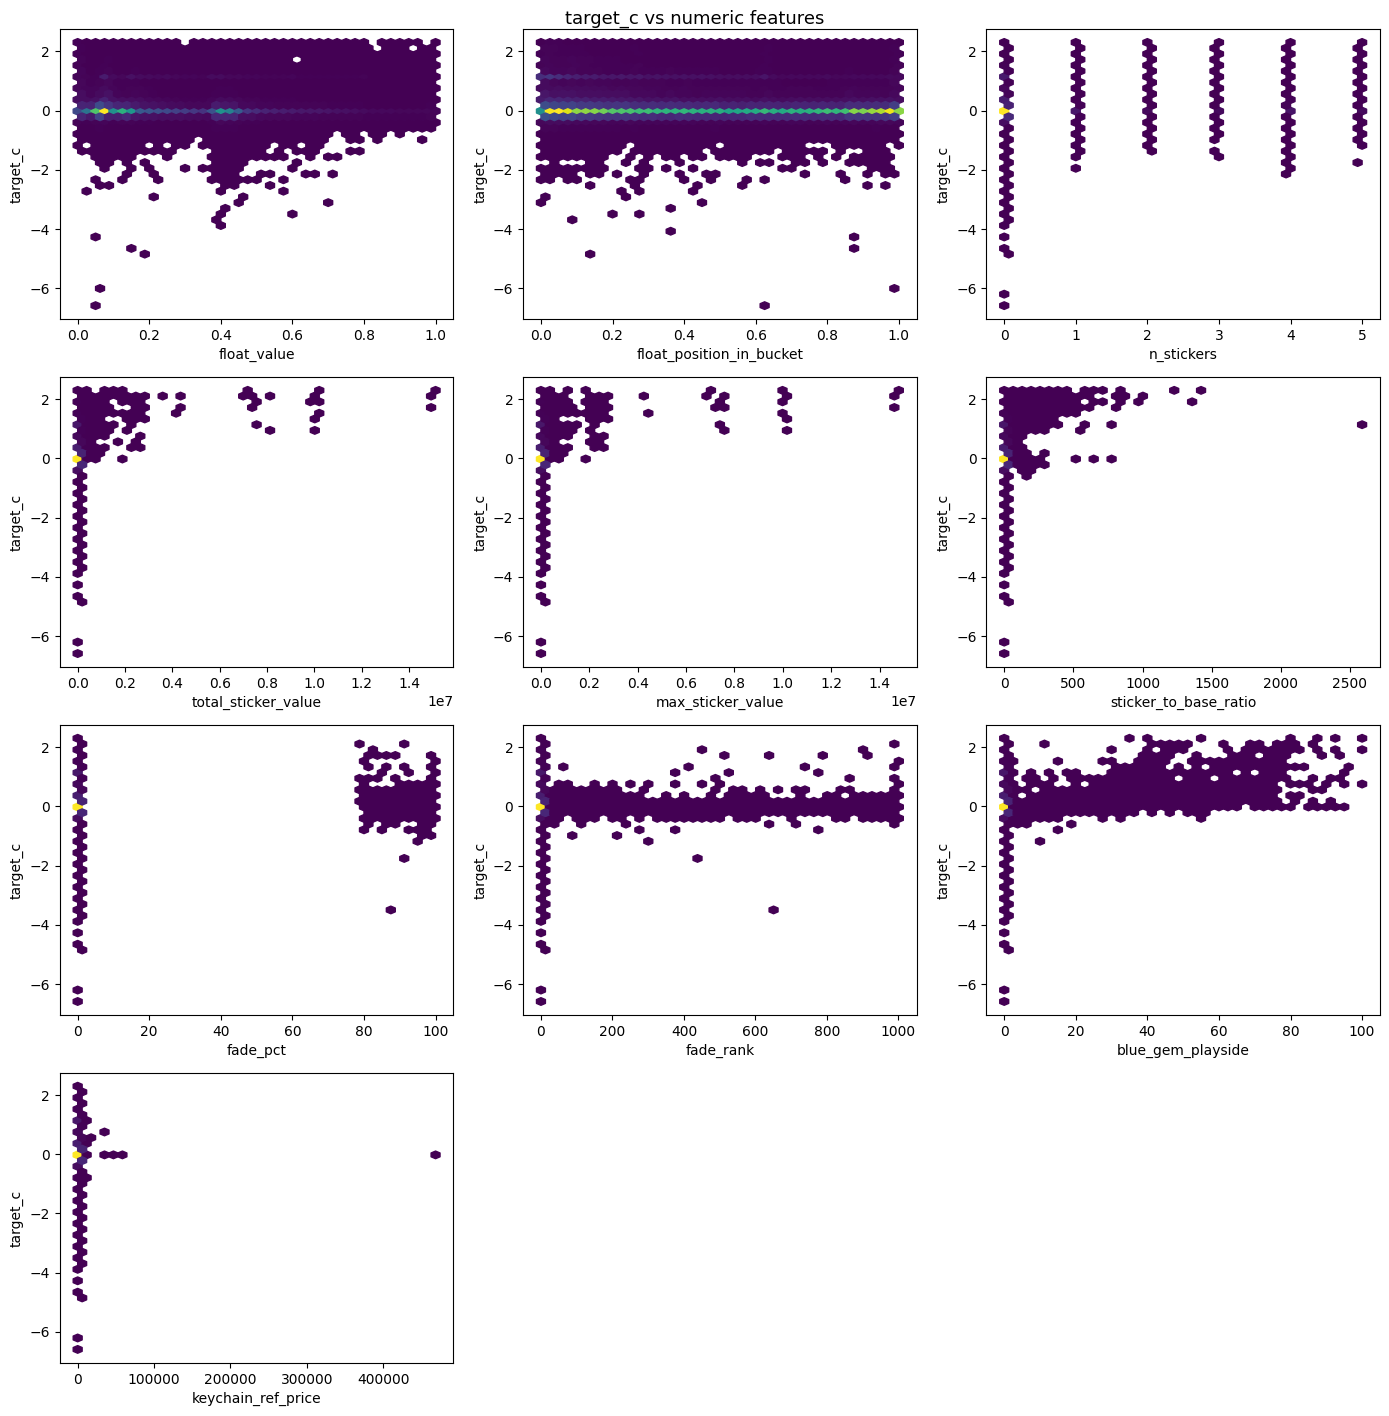

In [15]:
target_num_rel('target_c', 'target_c_vs_numeric.png')

## **8. Target vs Categorical Feature (Box Plots)**

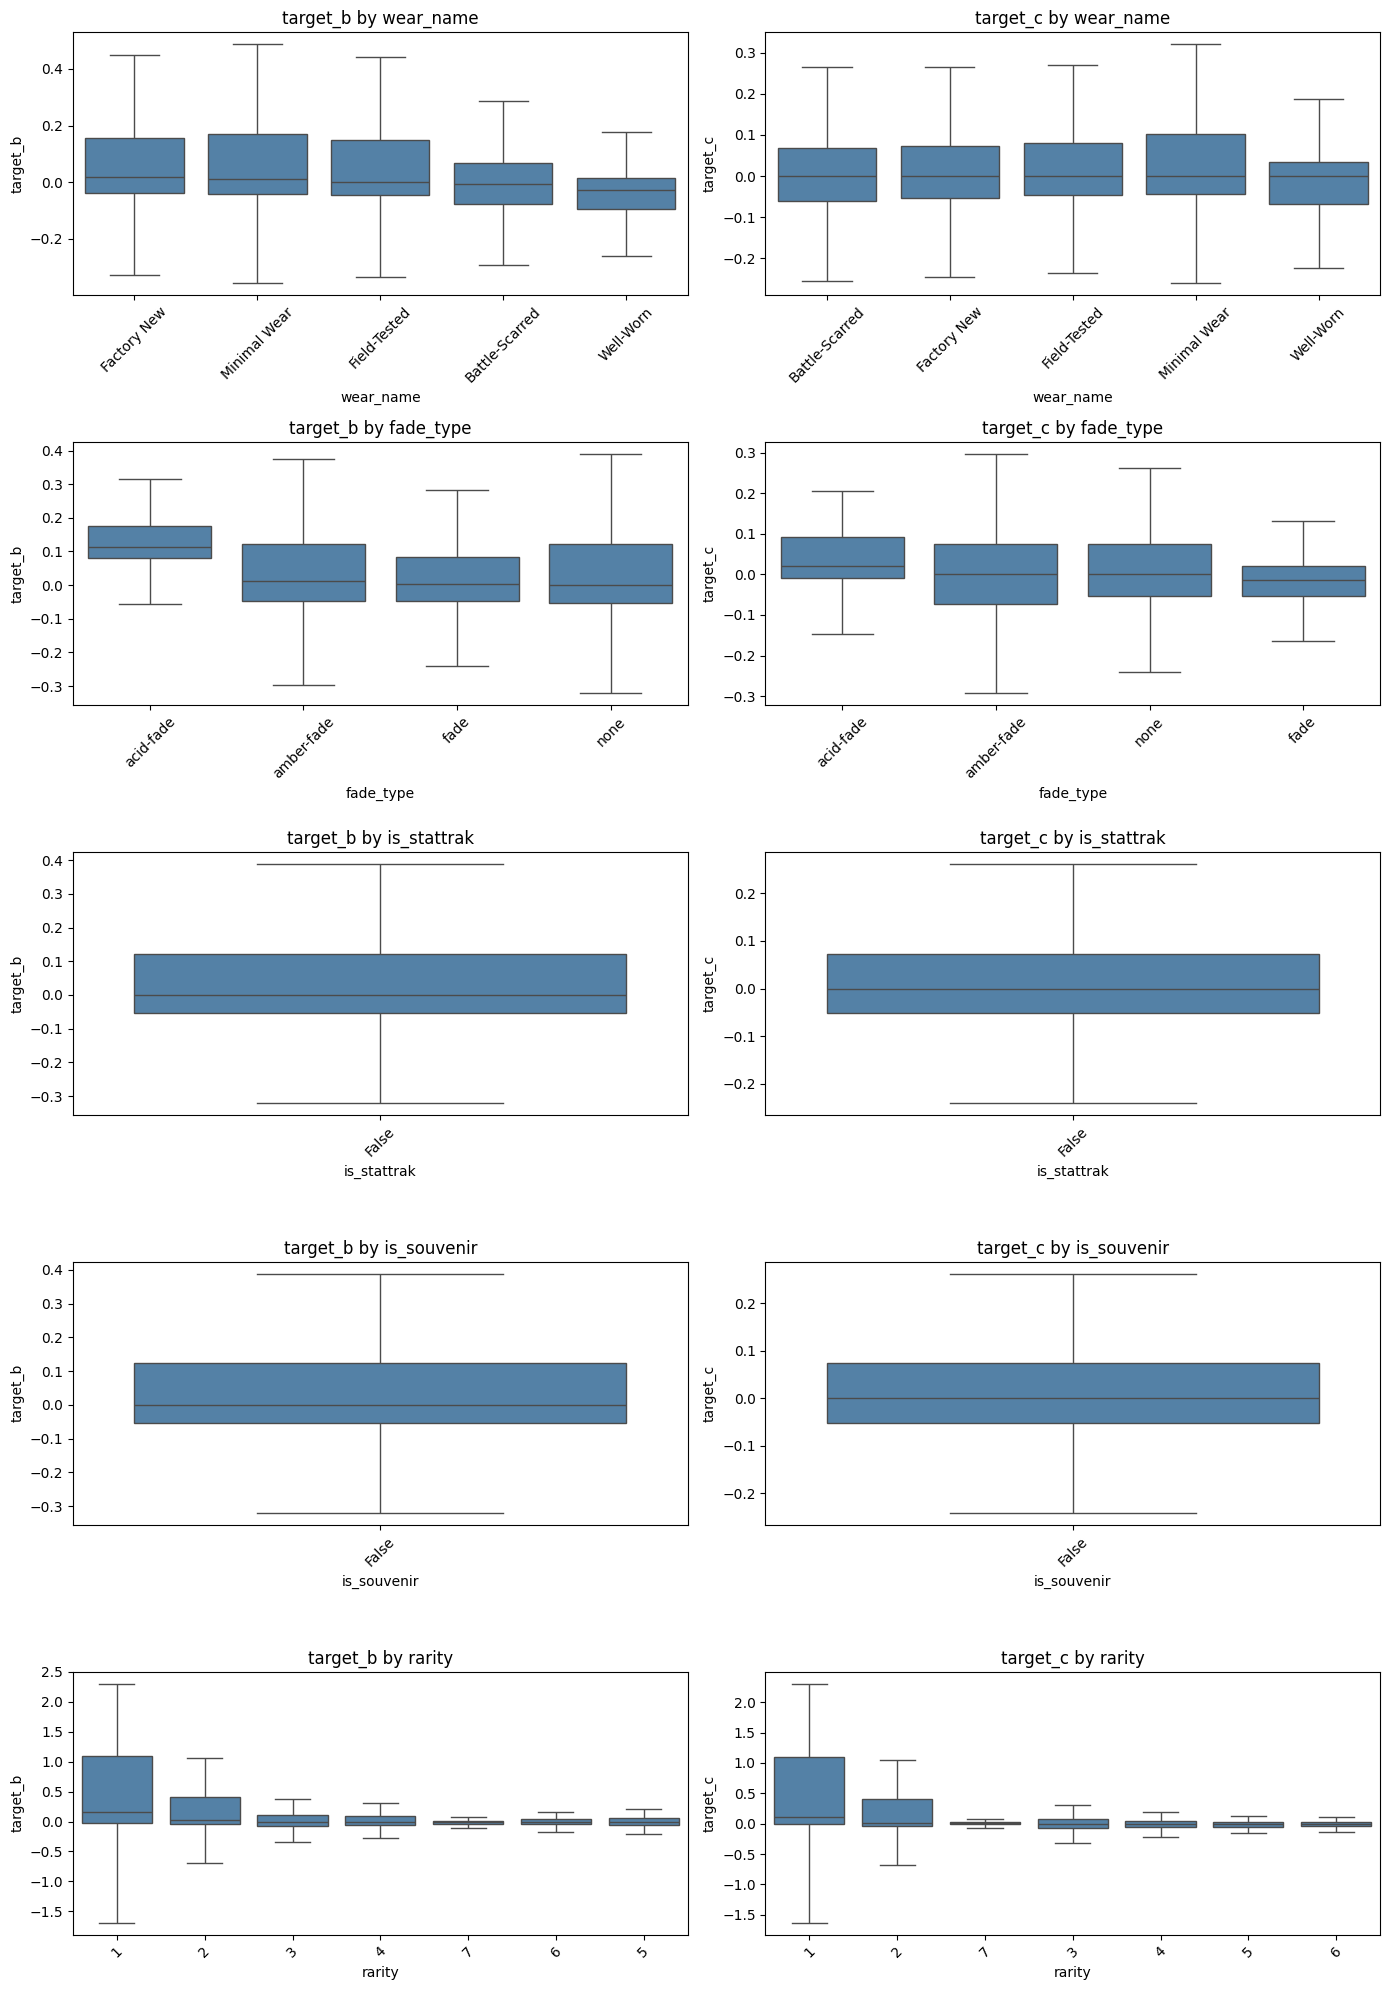

In [16]:
df_box = df.select(low_card_cols + target_cols).to_pandas()

fig, axes = plt.subplots(len(low_card_cols), 2, figsize=(14, 4 * len(low_card_cols)))

for row, col in enumerate(low_card_cols):
    for j, target_col in enumerate(target_cols):
        ax = axes[row, j]
        order = df_box.groupby(col)[target_col].median().sort_values(ascending=False).index
        sns.boxplot(data=df_box, x=col, y=target_col, order=order, ax=ax, showfliers=False, color='steelblue')
        ax.set_title(f'{target_col} by {col}')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'target_vs_categorical.png'), dpi=120, bbox_inches='tight')
plt.show()

## **9. Ranked Correlation with Targets**

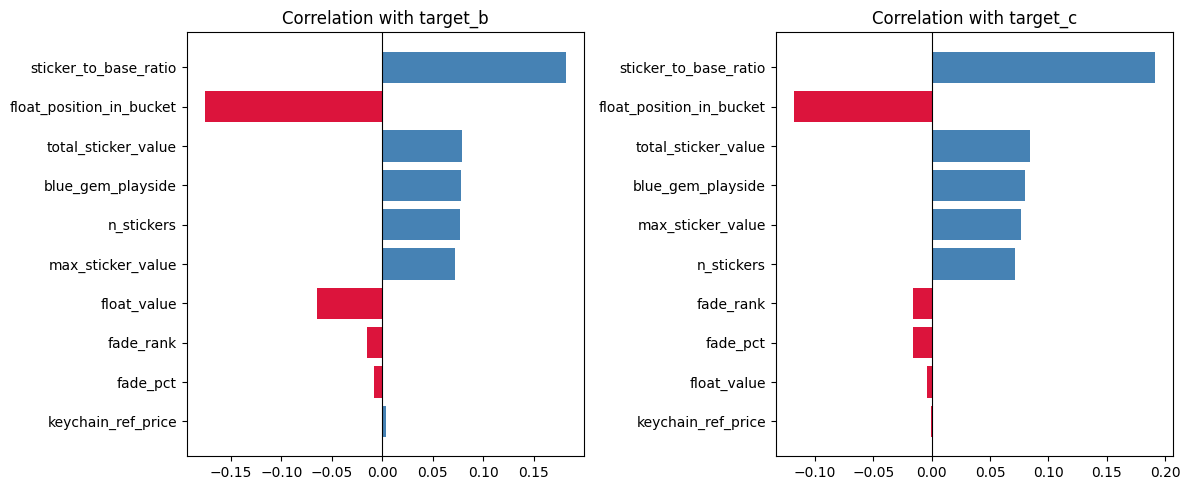

                          target_b  target_c
sticker_to_base_ratio     0.181877  0.191046
float_position_in_bucket -0.175835 -0.118346
total_sticker_value       0.079437  0.084217
blue_gem_playside         0.077947  0.079626
n_stickers                0.077090  0.071537
max_sticker_value         0.072120  0.076586
float_value              -0.064645 -0.004460
fade_rank                -0.015216 -0.016455
fade_pct                 -0.008099 -0.015760
keychain_ref_price        0.004097 -0.000313


In [10]:
target_corr = corr_mat.loc[numeric_cols, target_cols]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target_col in zip(axes, target_cols):
    ranked = target_corr[target_col].reindex(target_corr[target_col].abs().sort_values(ascending=True).index)
    colors = ['crimson' if v < 0 else 'steelblue' for v in ranked]
    ax.barh(ranked.index, ranked.values, color=colors)
    ax.set_title(f'Correlation with {target_col}')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print(target_corr.sort_values('target_b', key=lambda s: s.abs(), ascending=False).to_string())

## **10. Observations**

- **`sticker_to_base_ratio` is the strongest single linear signal** for both targets (`r = 0.182` for `target_b`, `0.191` for `target_c`) — sticker premium tracks overpay directly, as expected.
- **`float_position_in_bucket` is the second strongest** (`r = -0.176` / `-0.118`) and clearly beats raw `float_value` (`r = -0.065` / `-0.004`) — the bucket-normalized transform recommended in `CLAUDE.md` is validated empirically: low-float-within-bucket premium is real, and normalizing captures much more of it than the raw float does. `target_c`'s float correlation nearly vanishes (`-0.004`) — consistent with `ref_predicted_price` already pricing in float via CSFloat's own Float Appraiser, leaving little residual float signal for the Model C target to explain.
- The other sticker features (`total_sticker_value`, `max_sticker_value`, `n_stickers`) and `blue_gem_playside` sit in a weak-but-consistent positive band (`r ≈ 0.07–0.08`) for both targets.
- `fade_pct`, `fade_rank`, `keychain_ref_price` show ~zero linear correlation (`|r| < 0.016`). This likely reflects sparsity (only 2,518 / 361,239 rows, ~0.7%, have a non-`"none"` `fade_type`) rather than true irrelevance — not enough support for a stable linear read, and any real fade premium is probably non-linear/threshold-like (kicks in only near 90–100% fade), which a GBDT should pick up but a linear model (Model A) likely won't.
- **All correlations are weak in absolute terms (max `|r| = 0.19`)** — expected for this kind of noisy per-listing pricing target, and it's the core justification for Model B/C being GBDTs rather than linear: overpay looks like it comes from feature *interactions* (e.g. sticker value × float position, matched-set bonus) that a correlation matrix can't see. Model A (linear) should be read as a floor, not a target to match.
- **Data quality flag**: `is_stattrak` and `is_souvenir` are both **constant (`False`) across all 361,239 rows** in the current snapshot accumulation — no StatTrak/Souvenir sales have been ingested yet for the 40 starter skins. These two features carry zero signal right now and should be dropped from training until StatTrak/Souvenir history is backfilled, otherwise they're dead weight for CatBoost.
- `def_index` (35 unique weapons) and `rarity` (7 tiers, tier 7 = Covert/knives only 171 rows) are reasonably distributed for CatBoost's native categorical handling, but tier 7 is thin — expect higher variance in its target estimates.
- `paint_seed` has 1,001 unique values, confirming it must go through the pattern lookup table (blue gem tiers, Doppler phase, etc.) rather than being fed as a raw int, per `CLAUDE.md`.